In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation
from skimage import draw
from scipy.ndimage import gaussian_filter1d
from PhantomGenerators import RectangleDist, EllipseDist, CreateBlob, CartesianToPolar, ShrinkShape, EdgeImage, DifferentGrayLevels, DifferentGrayDistBased
from os import mkdir

rng = np.random.default_rng(67)
baseDim = 512
baseImg = np.zeros((baseDim, baseDim))

MAX_GRAY_VAL = 255
MIN_GRAY_VAL = 0
BASE_DIM = 512
IMG_SHAPE = (512, 512)
BASE_IMG = np.zeros(IMG_SHAPE)
RNG = np.random.default_rng(seed=67)


if not os.path.exists("Pixel_phantom/phantom_arrays"):
    mkdir("Pixel_phantom/phantom_arrays")

### Granular texture

We can create a granular texture by generating gaussian noise, smoothing it again with a gaussian filter, and then using a threshold function to clip it to the maximum, or minimum intesity.

Unique gray values: [  0. 255.]


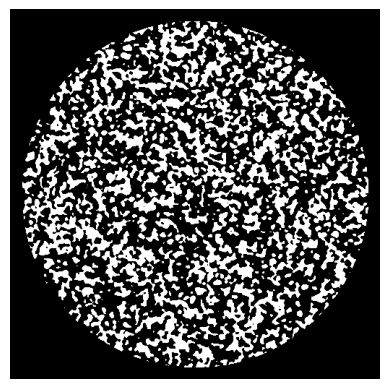

In [4]:
"""Random noise confined in circel"""

noise = RNG.standard_normal(IMG_SHAPE)
smooth = gaussian_filter(noise, sigma=2)
clippedSmooth = np.clip(smooth, 0, 1)

# Make the image binary
threshold = 0.04
clippedSmooth[clippedSmooth > threshold] = 1
clippedSmooth[clippedSmooth <= threshold] = 0

# Define circular field
radius = 240
center = np.array(IMG_SHAPE) // 2
rr, cc = draw.ellipse(center[0], center[1], radius, radius, shape=IMG_SHAPE)

# Use circular field to define a mask
mask = np.ones_like(baseImg)
mask[rr, cc] = 0

# Set everything outside the circle equal to 0
clippedSmooth[mask.astype(bool)] = 0

clippedSmooth *= MAX_GRAY_VAL
clippedSmooth[clippedSmooth > MAX_GRAY_VAL] = MAX_GRAY_VAL
clippedSmooth[clippedSmooth < MIN_GRAY_VAL] = MIN_GRAY_VAL

print("Unique gray values:", np.unique(clippedSmooth))
plt.imshow(clippedSmooth, cmap='gray')
plt.axis('off')
plt.savefig("Pixel_phantom/granular_phantom_single_grayvalues.png", bbox_inches='tight')
plt.show()

np.savez("Pixel_phantom/phantom_arrays/granular_phantom_single_grayvalues", clippedSmooth)

### Adding different gray levels

We can add different gray levels using `DifferentGrayDistBased`, which assigns different gray values based on the distance of that pixel away from a user defined center ((256, 256)). Note that it only assigns a different colour to pixels that have a gray value larger than zero, as zero is considered to be the background.

Unique gray values: [  0.  127.5 255. ]


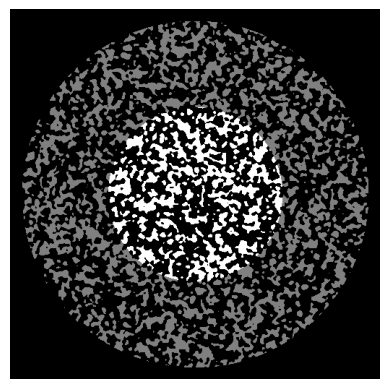

In [5]:
img3 = DifferentGrayDistBased((256, 256), clippedSmooth, levels=3)

print("Unique gray values:", np.unique(img3))
plt.imshow(img3, cmap='gray')
plt.axis('off')
plt.savefig("Pixel_phantom/granular_phantom_2_grayvalues.png", bbox_inches='tight')
plt.show()

np.savez("Pixel_phantom/phantom_arrays/granular_phantom_2_grayvaluess", img3)

We can vary the amount of levels to create more rings

Unique gray values: [  0.  85. 170. 255.]


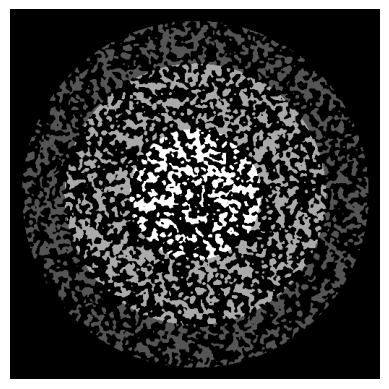

In [6]:
img2 = DifferentGrayDistBased((256, 256), clippedSmooth, levels=4)

print("Unique gray values:", np.unique(img2))
plt.imshow(img2, cmap='gray')
plt.axis('off')
plt.savefig("Pixel_phantom/granular_phantom_multiple_grayvalues.png", bbox_inches='tight')
plt.show()

np.savez("Pixel_phantom/phantom_arrays/granular_phantom_multiple_grayvalues", img2)


### Porouse Structure

To create a porouse structure which has different densities we create first the porouse part using the same technique for the granular structure but with a larger standard deviation and a heavier smoothing. To illustrate the different densities we overlap parts of ellipses to create very dense areas. At last we dont want the entire image to be contained by this porouse structure so we overlap black parts to cover parts of it. This is done by drawing two circles that have irregular edges using the `CreateBlob` function. This function accepts a center, dimensions of the shape (width, height), what shape the function is (can be a callable or the edge image of a random shape), how big the noise amplitude is, how much smoothing of the noise to create a smoother change of the edge, amount of points, and how to rotate the shape. 

Unique gray values: [  0. 255.]


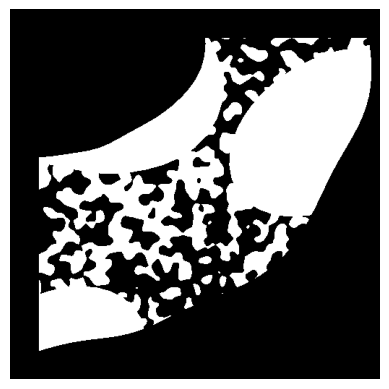

In [7]:

# Lower density porous structure
noise = rng.normal(0, 5, size=IMG_SHAPE)
smooth = gaussian_filter(noise, sigma=5)
porouseSmooth = np.clip(smooth, 0, 1)

threshold = 0.035
porouseSmooth[porouseSmooth > threshold] = 1
porouseSmooth[porouseSmooth <= threshold] = 0


# ------------ Upper left dark spot and denser structure -----------

# Dense part
r, c= CreateBlob(center=(75, 100), width=150, height=200, radiusFunction=EllipseDist, noise_amplitude=10, sigma=2, num_points=50, rot=-1/4)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
porouseSmooth[rr, cc] = 1

r, c= CreateBlob(center=(500, 50), width=150, height=100, radiusFunction=EllipseDist, noise_amplitude=00, sigma=2, num_points=50, rot=-1)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
porouseSmooth[rr, cc] = 1

r, c= CreateBlob(center=(170, 440), width=150, height=100, radiusFunction=EllipseDist, noise_amplitude=00, sigma=2, num_points=50, rot=-1)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
porouseSmooth[rr, cc] = 1

# Dark spots
innerR = 200
r, c= CreateBlob(center=(0, 20), width=innerR, height=innerR+50, radiusFunction=EllipseDist, noise_amplitude=20, sigma=2.5, num_points=100, rot=-1/4)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)

r, c= CreateBlob(center=(50, 50), width=440, height=440, radiusFunction=EllipseDist, noise_amplitude=50, sigma=4, num_points=200, rot=0)
bigRR, bigCC = draw.polygon(r, c, shape=IMG_SHAPE)

mask = np.zeros_like(BASE_IMG)
mask[rr, cc] = 1
mask[0:40,:] = 1
mask[:,0:40] = 1

mask2 = np.ones_like(BASE_IMG)
mask2[bigRR, bigCC] = 0

# Set everything inside the circle equal to 0
porouseSmooth[mask.astype(bool)] = 0
porouseSmooth[mask2.astype(bool)] = 0

porouseSmooth *= MAX_GRAY_VAL
porouseSmooth[porouseSmooth > MAX_GRAY_VAL] = MAX_GRAY_VAL
porouseSmooth[porouseSmooth < MIN_GRAY_VAL] = MIN_GRAY_VAL

print("Unique gray values:", np.unique(porouseSmooth))
plt.imshow(porouseSmooth, cmap='gray')
plt.axis('off')
plt.savefig("Pixel_phantom/Porouse_with_different_density.png", bbox_inches='tight')
plt.show()

np.savez("Pixel_phantom/phantom_arrays/Porouse_with_different_density", porouseSmooth)


### Random pixelized phantom

This phantom was created by overlapping different types of shapes of which the edges are modified by the `CreateBlob` function. 

Unique gray values: [  0. 255.]


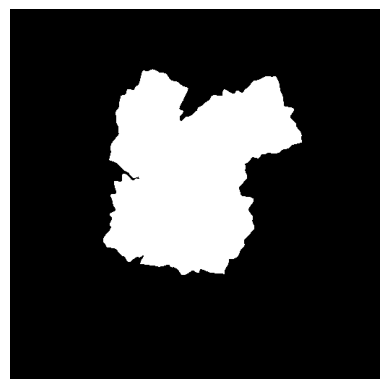

In [8]:
""""Random shape pixel based phantom"""

img = BASE_IMG.copy()

r_total, c_total = [], []

r, c= CreateBlob(center=(160, 330), width=100, height=120, radiusFunction=RectangleDist, noise_amplitude=8, sigma=2, num_points=200, rot=3/8)
r_total += list(r)
c_total += list(r)
upRightRectRr, upRightRectCc = draw.polygon(r, c, shape=IMG_SHAPE)
img[upRightRectRr, upRightRectCc] = 1

middleCircleR = 74
r, c= CreateBlob(center=(220, 250), width=middleCircleR, height=middleCircleR, radiusFunction=EllipseDist, noise_amplitude=10, sigma=2, num_points=200, rot=3/8)
r_total += list(r)
c_total += list(r)
middleCircleRr, middleCircleCc = draw.polygon(r, c, shape=IMG_SHAPE)
img[middleCircleRr, middleCircleCc] = 1

r, c= CreateBlob(center=(160, 190), width=140, height=70, radiusFunction=RectangleDist, noise_amplitude=8, sigma=2, num_points=200, rot=-3/8)
r_total += list(r)
c_total += list(r)
upLeftRectRr, upLeftRectCc = draw.polygon(r, c, shape=IMG_SHAPE)
img[upLeftRectRr, upLeftRectCc] = 1

r, c= CreateBlob(center=(290, 180), width=110, height=80, radiusFunction=RectangleDist, noise_amplitude=10, sigma=2, num_points=200, rot=-2/8)
r_total += list(r)
c_total += list(r)
lowLeftRectRr, lowLeftRectCc = draw.polygon(r, c, shape=IMG_SHAPE)
img[lowLeftRectRr, lowLeftRectCc] = 1

r, c= CreateBlob(center=(330, 240), width=60, height=120, radiusFunction=RectangleDist, noise_amplitude=5, sigma=1, num_points=100, rot=-1/9)
r_total += list(r)
c_total += list(r)
lowMiddleRectRr, lowMiddleRectCc = draw.polygon(r, c, shape=IMG_SHAPE)
img[lowMiddleRectRr, lowMiddleRectCc] = 1

lowerMiddleCircleR = 74
r, c= CreateBlob(center=(290, 260), width=middleCircleR, height=lowerMiddleCircleR, radiusFunction=EllipseDist, noise_amplitude=10, sigma=2, num_points=200, rot=3/8)
r_total += list(r)
c_total += list(r)
middleCircleRr, middleCircleCc = draw.polygon(r, c, shape=IMG_SHAPE)
img[middleCircleRr, middleCircleCc] = 1

upperLeftCircleR = 44
r, c= CreateBlob(center=(150, 190), width=upperLeftCircleR, height=upperLeftCircleR, radiusFunction=EllipseDist, noise_amplitude=4, sigma=2, num_points=200, rot=0)
r_total += list(r)
c_total += list(r)
middleCircleRr, middleCircleCc = draw.polygon(r, c, shape=IMG_SHAPE)
img[middleCircleRr, middleCircleCc] = 1

img *= MAX_GRAY_VAL
img[img > MAX_GRAY_VAL] = MAX_GRAY_VAL
img[img < MIN_GRAY_VAL] = MIN_GRAY_VAL

print("Unique gray values:", np.unique(img))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.savefig("Pixel_phantom/Random_shape.png", bbox_inches='tight')
plt.show()

np.savez("Pixel_phantom/phantom_arrays/Random_shape", img)


### Add another gray value

To add another gray value to the image, you can extract the edge of a shape using the `EdgeImage` function. This is followed by a shrinking of the shape so it can fit inside the other shape that was already present in the figure. You can also decide to smooth the edges more or rotate it with the `ShrinkShape` function. To then really get the coordinates and possibly change the boundaries of the shape more you can convert the raw pixel coordinates of the edge of the shrunken image to polar coordinates using `CartesianToPolar`, and pass it into the `CreateBlob` function. Note that we passed the radius, angles into the `CreateBlob` function instead of a the `EllipseDist` or `RectangleDist` callables. This way the `CreateBlob` can alter any shape. This shrunken, rotated, altered, and shifted shape is then added to the image with a different gray value.

Unique gray values: [  0. 204. 255.]


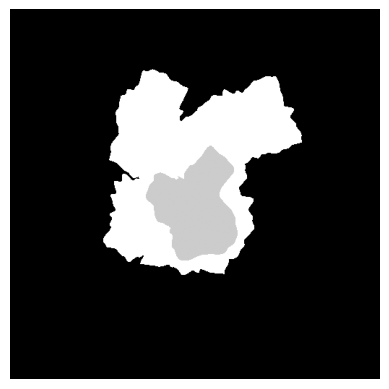

In [9]:
img2 = img.copy()

edgeR, edgeC = EdgeImage(img2)
shrinkR, shrinkC = ShrinkShape(edgeR, edgeC, 0.5, smoothing=20, rot=-0.5)
radius, theta  = CartesianToPolar(shrinkR, shrinkC)
blobR, blobC= CreateBlob(center=(270, 256), width=0, height=0, radiusFunction=radius, noise_amplitude=20, sigma=20, num_points=0, rot=0, theta=theta)
shrinkRR, shrinkCC = draw.polygon(blobR, blobC, shape=IMG_SHAPE)
img2[shrinkRR, shrinkCC] = 0.8 * MAX_GRAY_VAL

img2[img2 > MAX_GRAY_VAL] = MAX_GRAY_VAL
img2[img2 < MIN_GRAY_VAL] = MIN_GRAY_VAL

print("Unique gray values:", np.unique(img2))
plt.imshow(img2, cmap='gray')
plt.axis('off')
plt.savefig("Pixel_phantom/Random_shape_2_gray.png", bbox_inches='tight')
plt.show()

np.savez("Pixel_phantom/phantom_arrays/Random_shape_2_gray", img2)


Another demonstration of creating more gray levels with `DifferentGrayLevels` 

Unique gray values: [  0.  85. 170. 255.]


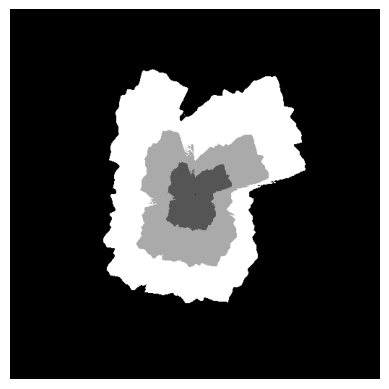

In [10]:
import importlib
import PhantomGenerators

importlib.reload(PhantomGenerators)

img3 = DifferentGrayLevels(img, 4)

print("Unique gray values:", np.unique(img3))
plt.imshow(img3, cmap='gray')
plt.axis('off')
plt.savefig("Pixel_phantom/Random_shape_multipl_gray.png", bbox_inches='tight')
plt.show()

np.savez("Pixel_phantom/phantom_arrays/Random_shape_multipl_gray", img3)


Unique gray values: [  0.   25.5 102.  178.5]


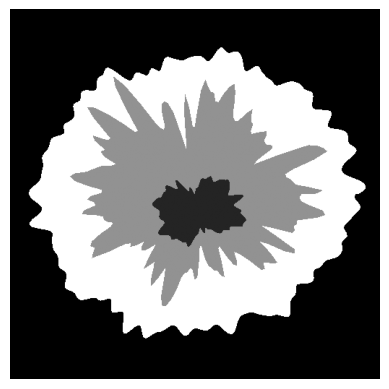

In [11]:
img = BASE_IMG.copy()

# Outer shape (gray = 0.7)
r_out, c_out = CreateBlob(center=(256,256), width=190, height=220, 
                          radiusFunction=EllipseDist, noise_amplitude=20, sigma=2, num_points=400)
rr_out, cc_out = draw.polygon(r_out, c_out, shape=IMG_SHAPE)
img[rr_out, cc_out] = 0.7

# Inner shape (gray = 0.4)
r_in, c_in = CreateBlob(center=(256,256), width=120, height=150, 
                        radiusFunction=EllipseDist, noise_amplitude=40, sigma=1, num_points=200)
rr_in, cc_in = draw.polygon(r_in, c_in, shape=IMG_SHAPE)
img[rr_in, cc_in] = 0.4

# Even smaller inner shape (gray = 0.1)
r_small, c_small = CreateBlob(center=(280,260), width=70, height=110,
                               radiusFunction=RectangleDist, noise_amplitude=15, sigma=2, rot=2/8)
r, theta  = CartesianToPolar(r_small, c_small)
rr_small, cc_small = draw.polygon(r_small, c_small, shape=IMG_SHAPE)
img[rr_small, cc_small] = 0.1

img *= MAX_GRAY_VAL
img[img > MAX_GRAY_VAL] = MAX_GRAY_VAL
img[img < MIN_GRAY_VAL] = MIN_GRAY_VAL

print("Unique gray values:", np.unique(img))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.savefig("Pixel_phantom/multiple_random_shapes_different_gray.png", bbox_inches='tight')
plt.show()

np.savez("Pixel_phantom/phantom_arrays/multiple_random_shapes_different_gray", img)


### Binary gray levels shape with holes

This irregullar shpae is made by putting togheter multiple shapes that are created with the `CreateBlob` function. 

Unique gray values: [  0. 255.]


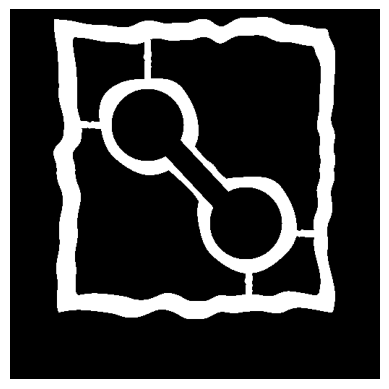

In [12]:
img = BASE_IMG.copy()

# -------------- Outer Frame
r, c = CreateBlob(center=(220, 256), width=400, height=380, radiusFunction=RectangleDist, noise_amplitude=15, sigma=4, num_points=500)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 1

edgeR, edgeC = EdgeImage(img)
edgeR, edgeC = ShrinkShape(edgeR, edgeC, shrinkFactor=0.88, smoothing=5)
radius, theta = CartesianToPolar(edgeR, edgeC)
r, c = CreateBlob(center=(220, 256), width=0, height=0, radiusFunction=radius, noise_amplitude=0, sigma=4, num_points=450, theta=theta)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 0

# ------------- Inner Shapes -----------------

# White edges
r, c = CreateBlob(center=(236, 266), width=150, height=50, radiusFunction=RectangleDist, noise_amplitude=5, sigma=4, num_points=100, rot=0.75)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 1

r, c = CreateBlob(center=(160, 190), width=70, height=70, radiusFunction=EllipseDist, noise_amplitude=10, sigma=4, num_points=100)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 1

r, c = CreateBlob(center=(296, 326), width=70, height=70, radiusFunction=EllipseDist, noise_amplitude=10, sigma=4, num_points=100)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 1


# Upper bars
r, c = CreateBlob(center=(70, 190), width=60, height=10, radiusFunction=RectangleDist, noise_amplitude=2, sigma=2, num_points=100, rot=0)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 1

r, c = CreateBlob(center=(160, 110), width=10, height=60, radiusFunction=RectangleDist, noise_amplitude=2, sigma=2, num_points=100, rot=0)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 1

# Lower Bars
r, c = CreateBlob(center=(380, 330), width=40, height=10, radiusFunction=RectangleDist, noise_amplitude=2, sigma=2, num_points=100, rot=0)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 1

r, c = CreateBlob(center=(310, 400), width=10, height=60, radiusFunction=RectangleDist, noise_amplitude=2, sigma=2, num_points=100, rot=0)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 1


# Dark fillings inner shapes

r, c = CreateBlob(center=(160, 190), width=50, height=50, radiusFunction=EllipseDist, noise_amplitude=0, sigma=4, num_points=100)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 0

r, c = CreateBlob(center=(296, 326), width=50, height=50, radiusFunction=EllipseDist, noise_amplitude=0, sigma=4, num_points=100, rot=0)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 0


r, c = CreateBlob(center=(236, 266), width=150, height=30, radiusFunction=RectangleDist, noise_amplitude=0, sigma=4, num_points=100, rot=0.75)
rr, cc = draw.polygon(r, c, shape=IMG_SHAPE)
img[rr, cc] = 0



img *= MAX_GRAY_VAL
img[img > MAX_GRAY_VAL] = MAX_GRAY_VAL
img[img < MIN_GRAY_VAL] = MIN_GRAY_VAL

print("Unique gray values:", np.unique(img))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.savefig("Pixel_phantom/Random_structures_holes.png", bbox_inches='tight')
plt.show()

np.savez("Pixel_phantom/phantom_arrays/Random_structures_Holes", img)


